## Classification + regression on "forest fires" dataset

https://github.com/andrejensen302/Forest_Fires_data_analysis

The column **"area"** contains the area of forest burned.

There are **many zero values** because no fire occurred or the fire didn't spread.

In [48]:
import pandas as pd

df = pd.read_csv("hurdle_forestfires.csv")

df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


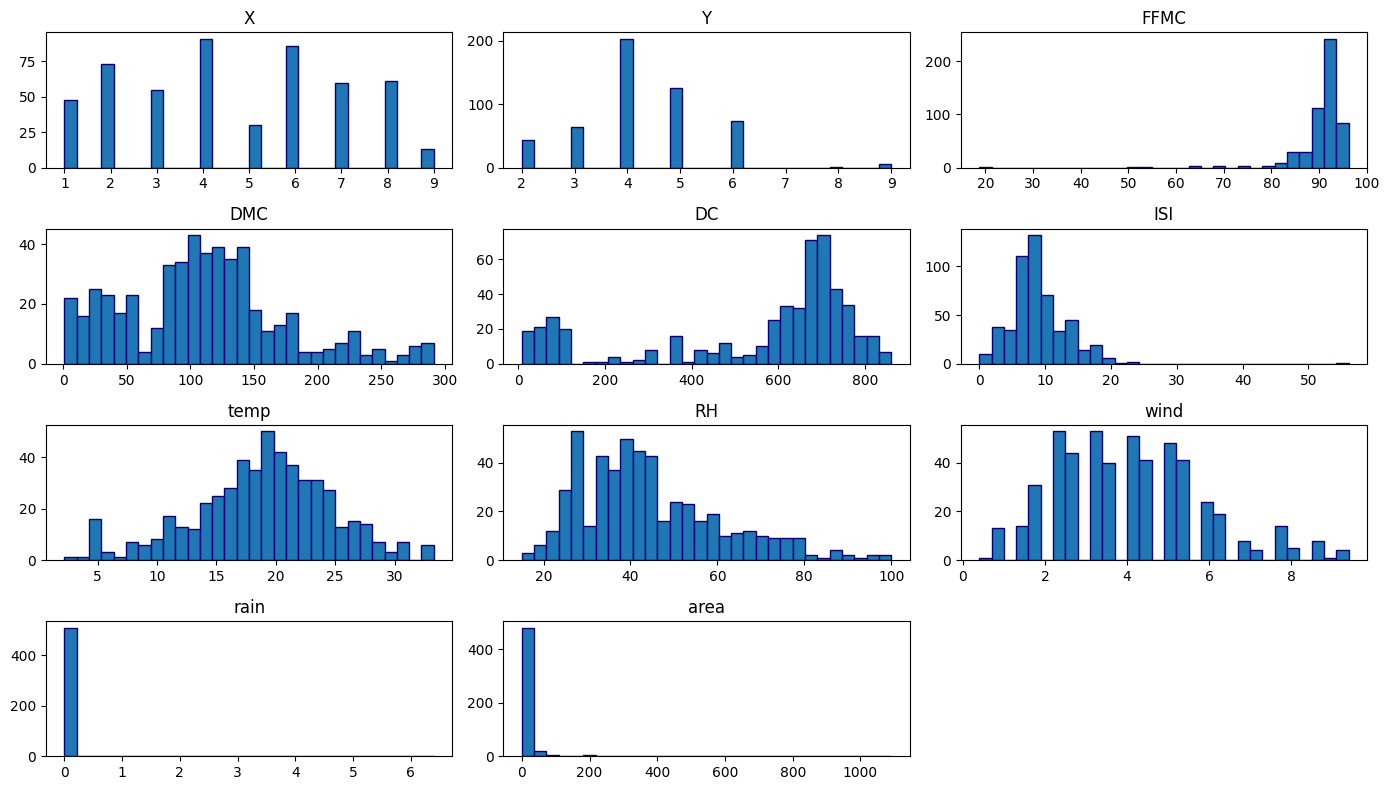

In [3]:
import matplotlib.pyplot as plt

def plot_histograms(df):
    '''Print histogram for all columns'''
    df.hist(figsize=(14, 8), bins=30, edgecolor='navy', grid=False)
    plt.tight_layout()
    plt.show()

plot_histograms(df)

In [49]:
y = df["area"]
X = df.drop(columns=["area"])

display(X, y)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0


0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
       ...  
512     6.44
513    54.29
514    11.16
515     0.00
516     0.00
Name: area, Length: 517, dtype: float64

In [50]:
# Check categorical columns

def get_all_categories(df):
    """Get names and unique values for every column with type 'object'"""

    obj_cols = df.select_dtypes(include=['object']).columns
    data = []

    for col in obj_cols:
        data.append({
            'column_name': col,
            'unique_values': df[col].unique().tolist(),
            'value_count': len(df[col].unique()),
        })
    
    return pd.DataFrame(data)

get_all_categories(X)

,column_name,unique_values,value_count
0,month,"[mar, oct, aug, sep, apr, jun, jul, feb, jan, ...",12
1,day,"[fri, tue, sat, sun, mon, wed, thu]",7


In [51]:
X_encoded = X.copy()

# Encode months
month_encoding = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12,
}
X_encoded["month"] = X_encoded["month"].map(month_encoding)

# Encode days
day_encoding = {
    "mon": 1,
    "tue": 2,
    "wed": 3,
    "thu": 4,
    "fri": 5,
    "sat": 6,
    "sun": 7,
}
X_encoded["day"] = X_encoded["day"].map(day_encoding)

X_encoded

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,3,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,10,2,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,10,6,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,3,5,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,3,7,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,8,7,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,8,7,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,8,7,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,8,6,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0


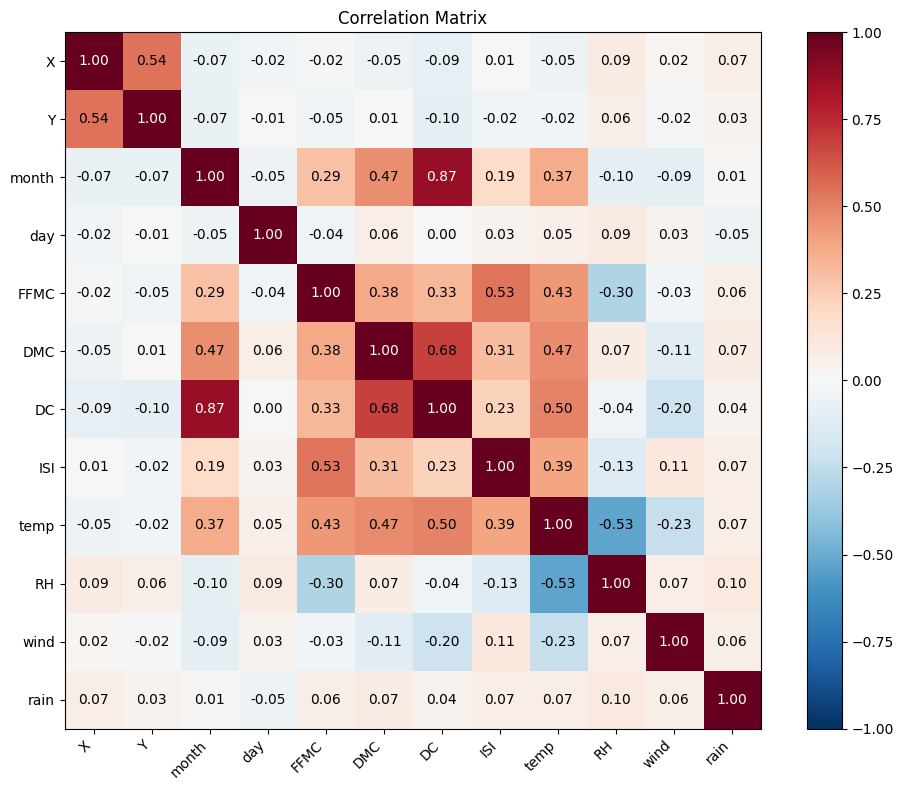

In [52]:
def show_correlation_matrix(df: pd.DataFrame):
    """
    Pure Matplotlib heatmap with automated text coloring for readability.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    corr = df.corr()
    fig, ax = plt.subplots(figsize=(10, 8))

    # Use 'RdBu_r' (reversed) so Red is positive, Blue is negative
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im)

    # Labels
    ticks = np.arange(len(corr.columns))
    ax.set_xticks(ticks)
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(ticks)
    ax.set_yticklabels(corr.columns)

    # Add text annotations with contrast logic
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            val = corr.iloc[i, j]
            # Use white text for very dark colors (strong correlations)
            color = "white" if abs(val) > 0.7 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color)

    ax.set_title("Correlation Matrix")
    fig.tight_layout()
    plt.show()

show_correlation_matrix(X_encoded)

In [53]:
# Split dataset

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2)


# Scale X data
# (not required for RandomForest)

# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler().set_output(transform="pandas")
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

display(X_train, X_test)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
55,4,3,9,4,92.9,137.0,706.4,9.2,27.7,24,2.2,0.0
276,4,4,12,1,85.4,25.4,349.7,2.6,4.6,21,8.5,0.0
415,8,6,8,4,94.8,222.4,698.6,13.9,27.5,27,4.9,0.0
308,2,4,9,7,92.4,105.8,758.1,9.9,16.0,45,1.8,0.0
439,1,3,9,5,91.1,91.3,738.1,7.2,19.1,46,2.2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
93,8,6,8,7,91.4,142.4,601.4,10.6,18.2,43,4.9,0.0
306,7,4,9,7,89.6,84.1,714.3,5.7,17.1,53,5.4,0.0
441,8,6,8,1,92.1,207.0,672.6,8.2,25.5,29,1.8,0.0
370,7,4,9,7,91.0,276.3,825.1,7.1,13.8,77,7.6,0.0


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
484,2,5,8,7,94.9,130.3,587.1,14.1,33.1,25,4.0,0.0
61,2,2,3,7,89.3,51.3,102.2,9.6,5.5,59,6.3,0.0
327,6,5,9,6,92.2,102.3,751.5,8.4,21.2,32,2.2,0.0
384,8,4,8,6,91.6,273.8,819.1,7.7,21.3,44,4.5,0.0
414,5,4,8,7,93.6,235.1,723.1,10.1,24.1,50,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
485,2,4,8,1,95.0,135.5,596.3,21.3,30.6,28,3.6,0.0
104,2,4,1,6,82.1,3.7,9.3,2.9,5.3,78,3.1,0.0
107,4,5,8,7,90.2,99.6,631.2,6.3,21.4,33,3.1,0.0
451,1,4,8,5,90.5,196.8,649.9,16.3,11.8,88,4.9,0.0


In [13]:
# Utility functions

import matplotlib.pyplot as plt
from sklearn.model_selection import LearningCurveDisplay
import numpy as np

def plot_learning_curve(model, X, y, classification: bool, cv=5):
    """
    Displays data size vs score. LearningCurveDisplay uses matplotlib under the hood.
    """

    display = LearningCurveDisplay.from_estimator(
        model,
        X,
        y,
        cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="accuracy" if classification else "r2",
    )
    display.ax_.set_title(f"Learning Curve: {model.__class__.__name__}")
    display.ax_.grid(True, linestyle="--", alpha=0.6)
    plt.show()

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
def show_confusion_matrix(model, y_test, y_pred):
    """Standard confusion matrix plot using Matplotlib backend."""
    if not hasattr(model, "classes_"):
        print("Model does not have classes_ attribute.")
        return

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(
        cmap="Blues", values_format=".4g"
    )  # values_format prevents scientific notation
    plt.title(f"Confusion Matrix: {model.__class__.__name__}")
    plt.show()


from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
def get_regression_metrics(y_test, y_pred) -> pd.DataFrame:
    """Calculates regression metrics"""
    metrics = {
        "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
        "Value": [
            mean_absolute_error(y_test, y_pred),
            mean_squared_error(y_test, y_pred),
            root_mean_squared_error(y_test, y_pred),
            r2_score(y_test, y_pred),
        ],
    }
    return pd.DataFrame(metrics).style.format({ "Value": "{:,.2f}" }) # Round to 2 decimals


from sklearn.metrics import classification_report
def get_classification_report(y_true, y_pred, target_names: list[str] | None = None) -> pd.DataFrame:
    """Converts sklearn report to a DataFrame."""
    report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    return pd.DataFrame(report_dict).transpose().round(2)

In [ ]:
# Part 1: train regressor on the entire dataset

In [15]:
# Run grid search on the whole dataset

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_reg = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(RandomForestRegressor(), param_reg, cv=5)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best params: {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 100}
Best score: -0.6785561095611534


In [ ]:
# Train regressor on the entire training data

best_params = {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 100}

# Initialize the model
model = RandomForestRegressor(**best_params)

# Fit the model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Check accuracy
get_regression_metrics(y_test, y_pred)

,Metric,Value
0,MAE,23.46
1,MSE,"11,501.19"
2,RMSE,107.24
3,R2 Score,0.01


In [59]:
# We can check the predicions manually if we want

pd.DataFrame({
    "y_test": y_test,
    "y_pred (regressor)": y_pred.round(2),
    "error": (y_pred - y_test).round(1),
})

,y_test,y_pred (regressor),error
484,26.43,18.59,-7.8
61,0.00,6.39,6.4
327,0.00,6.31,6.3
384,12.18,16.76,4.6
414,0.00,7.52,7.5
...,...,...,...
485,2.07,13.72,11.6
104,0.00,9.01,9.0
107,0.00,5.49,5.5
451,9.71,15.97,6.3


In [ ]:
# Part 2: prepare data for classifier and regressor

In [63]:
# Create train datasets for classifier

# Train
X_train_class = X_train # No change
y_train_class = (y_train > 0).astype(int) # Convert to 0 and 1

# Test
X_test_class = X_test # No change
y_test_class = (y_test > 0).astype(int) # Convert to 0 and 1

display(X_train_class, y_train_class)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
55,4,3,9,4,92.9,137.0,706.4,9.2,27.7,24,2.2,0.0
276,4,4,12,1,85.4,25.4,349.7,2.6,4.6,21,8.5,0.0
415,8,6,8,4,94.8,222.4,698.6,13.9,27.5,27,4.9,0.0
308,2,4,9,7,92.4,105.8,758.1,9.9,16.0,45,1.8,0.0
439,1,3,9,5,91.1,91.3,738.1,7.2,19.1,46,2.2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
93,8,6,8,7,91.4,142.4,601.4,10.6,18.2,43,4.9,0.0
306,7,4,9,7,89.6,84.1,714.3,5.7,17.1,53,5.4,0.0
441,8,6,8,1,92.1,207.0,672.6,8.2,25.5,29,1.8,0.0
370,7,4,9,7,91.0,276.3,825.1,7.1,13.8,77,7.6,0.0


55     0
276    1
415    1
308    0
439    1
      ..
93     0
306    1
441    1
370    1
430    0
Name: area, Length: 413, dtype: int64

In [64]:
# Create train datasets for regressor

# Train
X_train_reg = X_train[y_train > 0] # Keep only the rows where the target column is > 0
y_train_reg = y_train[y_train > 0] # Keep only the rows where the target column is > 0

# Test
X_test_reg = X_test # No change
y_test_reg = y_test # No change

display(X_train_reg, y_train_reg)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
276,4,4,12,1,85.4,25.4,349.7,2.6,4.6,21,8.5,0.0
415,8,6,8,4,94.8,222.4,698.6,13.9,27.5,27,4.9,0.0
439,1,3,9,5,91.1,91.3,738.1,7.2,19.1,46,2.2,0.0
366,4,5,9,2,91.1,132.3,812.1,12.5,15.9,38,5.4,0.0
221,3,4,9,5,93.3,141.2,713.9,13.9,18.6,49,3.6,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
472,8,3,6,1,88.2,96.2,229.0,4.7,14.3,79,4.0,0.0
138,9,9,7,2,85.8,48.3,313.4,3.9,18.0,42,2.7,0.0
306,7,4,9,7,89.6,84.1,714.3,5.7,17.1,53,5.4,0.0
441,8,6,8,1,92.1,207.0,672.6,8.2,25.5,29,1.8,0.0


276     17.85
415    746.28
439      0.33
366      1.75
221     35.88
        ...  
472      1.94
138      0.36
306      0.41
441      1.23
370     11.06
Name: area, Length: 219, dtype: float64

In [ ]:
# Run grid search on classifier

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 4],
    # 'class_weight': ['balanced'] # Important if 'fire' vs 'no fire' is imbalanced
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_search.fit(X_train_class, y_train_class)

print(f"Best params:", grid_search.best_params_)
print(f"Best score:", grid_search.best_score_)

Best params: {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 100}
Best score: 0.6029679694387305


In [67]:
# Run grid search on regressor

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=5)
grid_search.fit(X_train_reg, y_train_reg)

print(f"Best params:", grid_search.best_params_)
print(f"Best score:", grid_search.best_score_)

Best params: {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 100}
Best score: -0.7607251083420101


In [69]:
# Train classifier

best_params = {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 100}

model = RandomForestClassifier(**best_params)
model.fit(X_train_class, y_train_class)
y_pred_class = model.predict(X_test)

# Check score
get_classification_report(y_test_class, y_pred_class)

,precision,recall,f1-score,support
0,0.50,0.38,0.43,53.00
1,0.48,0.61,0.54,51.00
accuracy,0.49,0.49,0.49,0.49
macro avg,0.49,0.49,0.48,104.00
weighted avg,0.49,0.49,0.48,104.00


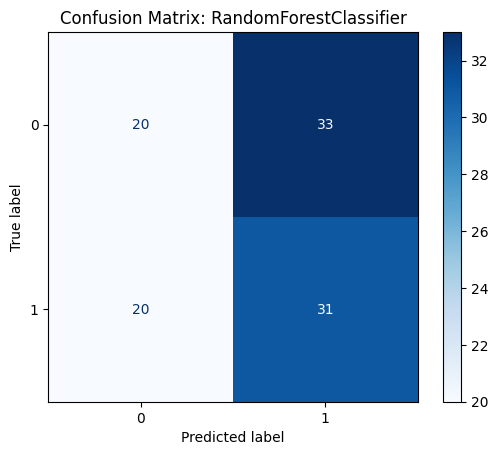

In [70]:
show_confusion_matrix(model, y_test_class, y_pred_class)

In [72]:
# Train final regressor

best_params = {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 100}

model = RandomForestRegressor(**best_params)
model.fit(X_train_reg, y_train_reg)
y_pred_reg = model.predict(X_test_reg)

# Check score
get_regression_metrics(y_test_reg, y_pred_reg)

,Metric,Value
0,MAE,34.19
1,MSE,"11,794.31"
2,RMSE,108.60
3,R2 Score,-0.02


In [ ]:
# Part 3: combine the two predictions (classifier + regressor)

In [73]:
import numpy as np

# Combine the predictions: if classifier says 0, area is 0; otherwise use the prediction from the regressor
y_pred_combined = np.where(y_pred_class == 0, 0, y_pred_reg)

# Check the results: classifier, regressor, combined
pd.DataFrame({
    "y_test": y_test,
    "y_pred (classifier)": y_pred_class,
    "y_pred (regressor)": y_pred_reg,
    "y_pred (combined)": y_pred_combined,
})

,y_test,y_pred (classifier),y_pred (regressor),y_pred (combined)
484,26.43,1,25.744392,25.744392
61,0.00,0,33.088511,0.000000
327,0.00,1,13.888455,13.888455
384,12.18,1,83.826298,83.826298
414,0.00,1,78.925476,78.925476
...,...,...,...,...
485,2.07,1,13.326282,13.326282
104,0.00,1,17.826216,17.826216
107,0.00,1,9.823150,9.823150
451,9.71,0,31.177147,0.000000


In [74]:
get_regression_metrics(y_test, y_pred_combined)

,Metric,Value
0,MAE,28.21
1,MSE,"11,691.70"
2,RMSE,108.13
3,R2 Score,-0.01


In [75]:
# 4. Final Evaluation

from sklearn.metrics import mean_absolute_error, classification_report

print("Classification score:")
print(classification_report(y_test_class, y_pred_class))

print("Regression score (MAE):")
print(round(mean_absolute_error(y_test, y_pred_combined), 2))

Classification score:
              precision    recall  f1-score   support

           0       0.50      0.38      0.43        53
           1       0.48      0.61      0.54        51

    accuracy                           0.49       104
   macro avg       0.49      0.49      0.48       104
weighted avg       0.49      0.49      0.48       104

Regression score (MAE):
28.21
